# Cosmic-Ray Shower Detection and Reconstruction

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/smaiti7/cosmic-ray-ml_sm/blob/main/Cosmic_Ray_ML_Colab.ipynb)

**Portable notebook: Deep Sets baseline plus a controlled Attention Deep Sets extension**

This notebook covers the required preprocessing, visualization, architecture, training, optimization, evaluation, and model comparison. It has two execution modes:

- `quick`: a short deterministic demonstration for Colab;
- `full`: the complete training protocol used for final-quality results.

Final reference metrics come from completed local GPU runs; quick-mode results are only demonstrations.

## 1. Physics objective and model choice

Each event contains **217 detector waveforms**, with **48 time bins per detector**. Signal events contain an extensive air shower, while background events contain noise, isolated hits, or instrumental bursts.

The model predicts:

1. shower probability;
2. logarithmic shower energy for signal events;
3. shower-core position `(x, y)` for signal events.

The baseline or **Original Deep Sets** model applies the same 1D CNN to every detector waveform, adds detector coordinates, and aggregates active detectors using masked mean, standard deviation, and maximum.

This follows the hierarchy

**time → detector → event**

and is independent of detector ordering.

The optional **Attention Deep Sets** model replaces fixed aggregation with learned detector weights. These weights indicate model importance, not physical causality.

## 2. Configuration

For a first run, keep:

- `RUN_MODE = "quick"`
- `MODEL_VARIANT = "original"`

Use `full` instead of `quick` only for complete training.

In [1]:
import os
import sys
import subprocess
from pathlib import Path

RUN_MODE = os.environ.get("COSMIC_RUN_MODE", "quick")       # "quick" or "full"
MODEL_VARIANT = os.environ.get("COSMIC_MODEL", "original") # "original" or "attention"
USE_GOOGLE_DRIVE = False
EVALUATE_TEST = False  # Set True only for the final selected full model.
REPO_URL = "https://github.com/smaiti7/cosmic-ray-ml_sm.git"
REPO_BRANCH = "main"

assert RUN_MODE in {"quick", "full"}
assert MODEL_VARIANT in {"original", "attention"}
if RUN_MODE == "quick":
    EVALUATE_TEST = False

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if "YOUR_USERNAME" in REPO_URL:
        raise ValueError("Replace YOUR_USERNAME/YOUR_REPOSITORY before uploading the notebook.")
    PROJECT_ROOT = Path("/content/cosmic-ray-ml")
    if not (PROJECT_ROOT / ".git").exists():
        subprocess.run(["git", "clone", "--depth", "1", "--branch", REPO_BRANCH, REPO_URL, str(PROJECT_ROOT)], check=True)
else:
    PROJECT_ROOT = Path.cwd().resolve()
    if not (PROJECT_ROOT / "cosmic_ml").exists():
        raise RuntimeError("Run this notebook from the repository root.")

if IN_COLAB and USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    DRIVE_ROOT = Path("/content/drive/MyDrive/cosmic_ray_ml")
    DEFAULT_OUTPUT_DIR = DRIVE_ROOT / "outputs" / f"{MODEL_VARIANT}_{RUN_MODE}"
    DEFAULT_ARCHIVE = DRIVE_ROOT / "cosmic_array_dataset.npz"
elif IN_COLAB:
    DRIVE_ROOT = None
    DEFAULT_OUTPUT_DIR = Path("/content/outputs") / f"{MODEL_VARIANT}_{RUN_MODE}"
    DEFAULT_ARCHIVE = Path("/content/data/cosmic_array_dataset.npz")
else:
    STORAGE_ROOT = Path(os.environ.get("COSMIC_STORAGE_ROOT", str(PROJECT_ROOT)))
    DRIVE_ROOT = None
    DEFAULT_OUTPUT_DIR = STORAGE_ROOT / "outputs" / f"{MODEL_VARIANT}_{RUN_MODE}"
    DEFAULT_ARCHIVE = STORAGE_ROOT / "data" / "cosmic_array_dataset.npz"

default_data = Path("/content/data") if IN_COLAB else STORAGE_ROOT / "data"
DATA_DIR = Path(os.environ.get("COSMIC_DATA_DIR", str(default_data)))
OUTPUT_DIR = Path(os.environ.get("COSMIC_OUTPUT_DIR", str(DEFAULT_OUTPUT_DIR)))
default_archive = DEFAULT_ARCHIVE if DRIVE_ROOT is not None else DATA_DIR / "cosmic_array_dataset.npz"
ARCHIVE_PATH = Path(os.environ.get("COSMIC_ARCHIVE_PATH", str(default_archive)))
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
ARCHIVE_PATH.parent.mkdir(parents=True, exist_ok=True)
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

print(f"Mode: {RUN_MODE}; model: {MODEL_VARIANT}; Colab: {IN_COLAB}")
print(f"Project: {PROJECT_ROOT}")
print(f"Data: {DATA_DIR}")
print(f"Output: {OUTPUT_DIR}")
print(f"Compressed archive/cache: {ARCHIVE_PATH}")

Mode: quick; model: original; Colab: True
Project: /content/cosmic-ray-ml
Data: /content/data
Output: /content/outputs/original_quick
Compressed archive/cache: /content/data/cosmic_array_dataset.npz


## 3. Environment and GPU check

In Colab, select **Runtime → Change runtime type → GPU** before running the training cells.

In [2]:
if IN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements-colab.txt"], check=True)

import json
import platform
import numpy as np
import torch

environment = {
    "python": platform.python_version(),
    "pytorch": torch.__version__,
    "cuda_available": torch.cuda.is_available(),
    "cuda_runtime": torch.version.cuda,
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
}
print(json.dumps(environment, indent=2))
if IN_COLAB and not torch.cuda.is_available():
    raise RuntimeError("No GPU detected. Select Runtime > Change runtime type > GPU and reconnect.")

{
  "python": "3.13.15",
  "pytorch": "2.11.0+cu128",
  "cuda_available": true,
  "cuda_runtime": "12.8",
  "gpu": "Tesla T4"
}


## 4. Download and prepare the dataset

The official compressed dataset is about 1.8 GB and expands to roughly 9.7 GB. The download script checks the exact expected byte count. Preparation extracts memory-mappable arrays, makes one deterministic seed-42 stratified 70/15/15 split, and computes every normalization statistic from training data only.

The waveform transform is `sign(x) × log(1 + |x|)`, which compresses the long positive tail without discarding negative electronic noise. Inactive detectors are explicitly masked.

In [3]:
archive = ARCHIVE_PATH
expected_bytes = 1_908_350_470
if not archive.exists() or archive.stat().st_size != expected_bytes:
    subprocess.run(["bash", "scripts/download_data.sh", str(archive)], check=True)
else:
    print(f"Using existing verified archive: {archive}")

local_archive = DATA_DIR / "cosmic_array_dataset.npz"
if archive.resolve() != local_archive.resolve():
    if not local_archive.exists():
        local_archive.symlink_to(archive)
        print(f"Linked runtime archive {local_archive} -> {archive}")
    elif local_archive.stat().st_size != expected_bytes:
        raise RuntimeError(f"Unexpected existing runtime archive: {local_archive}")

print("Extracted arrays stay on the fast runtime disk; Drive caches only the archive and outputs.")

subprocess.run([sys.executable, "-m", "cosmic_ml.prepare_data", "--data-dir", str(DATA_DIR)], check=True)
stats = json.loads((DATA_DIR / "processed" / "stats.json").read_text())
print(json.dumps(stats, indent=2))

Using existing verified archive: /content/data/cosmic_array_dataset.npz
Extracted arrays stay on the fast runtime disk; Drive caches only the archive and outputs.
{
  "seed": 42,
  "shape": {
    "events": 50000,
    "time_bins": 48,
    "detectors": 217
  },
  "split_sizes": {
    "train": 35000,
    "val": 7500,
    "test": 7500
  },
  "input": {
    "transform": "signed_log1p",
    "mean": 0.05882289169064094,
    "std": 0.6432887581588378
  },
  "positions": {
    "mean": [
      1.2851982662941904e-15,
      0.0
    ],
    "std": [
      6.711294558755254,
      6.711294558755254
    ]
  },
  "energy": {
    "mean": 0.9965912699699402,
    "std": 0.5774603486061096
  },
  "core": {
    "mean": [
      -0.0004016968887299299,
      0.12467467784881592
    ],
    "std": [
      9.60657024383545,
      9.701106071472168
    ]
  },
  "class_counts": {
    "0": 24824,
    "1": 25176
  },
  "active_detectors": {
    "min": 199,
    "mean": 210.50830078125,
    "max": 217
  }
}


## 5. Inspect geometry and one normalized waveform

These plots connect the tensor representation to the physical detector layout and time response.

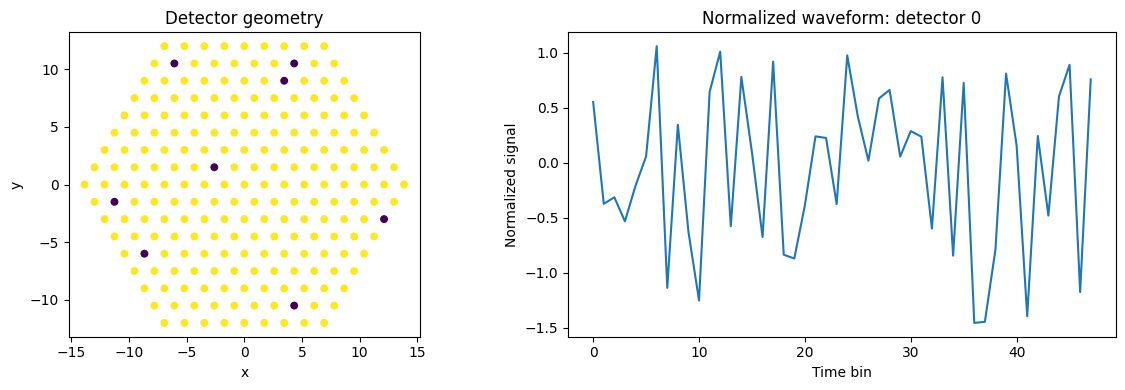

Tensor shape presented to the model: (217, 48) = (detectors, time bins)


In [4]:
import matplotlib.pyplot as plt
from cosmic_ml.data import CosmicDataset, load_splits

positions = np.load(DATA_DIR / "extracted" / "positions.npy")
splits = load_splits(DATA_DIR)
sample = CosmicDataset(splits["train"][:1], DATA_DIR, stats)[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(positions[:, 0], positions[:, 1], c=sample["mask"].numpy(), s=22, cmap="viridis")
axes[0].set(title="Detector geometry", xlabel="x", ylabel="y", aspect="equal")
active_index = int(torch.where(sample["mask"] > 0)[0][0])
axes[1].plot(sample["waveform"][active_index].numpy())
axes[1].set(title=f"Normalized waveform: detector {active_index}", xlabel="Time bin", ylabel="Normalized signal")
fig.tight_layout()
plt.show()
print(f"Tensor shape presented to the model: {tuple(sample['waveform'].shape)} = (detectors, time bins)")

## 6. Architecture check

Both model variants use the same temporal CNN, detector-coordinate encoder, event network, and three prediction heads. The only difference is how detector information is aggregated into a single event representation. The baseline model uses fixed statistical aggregation over active detectors, combining masked mean, standard deviation, and maximum, while the attention model learns different weights for the active detectors before combining them. Thus, the comparison isolates the effect of replacing fixed aggregation with learned attention-based aggregation.

In [5]:
from cosmic_ml.data import normalized_positions
from cosmic_ml.model import build_model, model_config

position_tensor = torch.from_numpy(normalized_positions(DATA_DIR, stats))
model = build_model(MODEL_VARIANT, position_tensor)
parameter_count = sum(parameter.numel() for parameter in model.parameters())
print(model)
print("Configuration:", model_config(model))
print(f"Trainable parameters: {parameter_count:,}")

TemporalDeepSet(
  (temporal_encoder): TemporalEncoder(
    (network): Sequential(
      (0): Conv1d(1, 16, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): GELU(approximate='none')
      (2): Conv1d(16, 24, kernel_size=(5,), stride=(2,), padding=(2,))
      (3): GELU(approximate='none')
      (4): Conv1d(24, 32, kernel_size=(3,), stride=(2,), padding=(1,))
      (5): GELU(approximate='none')
    )
    (projection): Sequential(
      (0): Linear(in_features=64, out_features=48, bias=True)
      (1): LayerNorm((48,), eps=1e-05, elementwise_affine=True)
      (2): GELU(approximate='none')
    )
  )
  (detector_encoder): Sequential(
    (0): Linear(in_features=50, out_features=64, bias=True)
    (1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): GELU(approximate='none')
  )
  (event_encoder): Sequential(
    (0): Linear(in_features=193, out_features=128, bias=True)
    (1):

## 7. Training and validation-controlled model selection

The loss is binary cross-entropy plus signal-only SmoothL1 energy and core losses. Background has no physical energy/core target, so those two terms are masked. AdamW, learning-rate reduction, gradient clipping, and early stopping are used. The best checkpoint is selected by total validation loss.

In [6]:
smoke = os.environ.get("COSMIC_SMOKE", "0") == "1"
if smoke:
    epochs, max_train, max_val = 1, 128, 64
elif RUN_MODE == "quick":
    epochs, max_train, max_val = 5, 5000, 1000
else:
    epochs, max_train, max_val = 40, None, None

command = [
    sys.executable, "-m", "cosmic_ml.train",
    "--model-type", MODEL_VARIANT,
    "--data-dir", str(DATA_DIR),
    "--output-dir", str(OUTPUT_DIR),
    "--epochs", str(epochs),
    "--batch-size", "64",
    "--num-workers", "2" if IN_COLAB else "0",
    "--device", "cuda" if torch.cuda.is_available() else "cpu",
]
if max_train is not None:
    command += ["--max-train-samples", str(max_train), "--max-val-samples", str(max_val)]

print("Running:", " ".join(command))
subprocess.run(command, check=True)

Running: /usr/bin/python3 -m cosmic_ml.train --model-type original --data-dir /content/data --output-dir /content/outputs/original_quick --epochs 5 --batch-size 64 --num-workers 2 --device cuda --max-train-samples 5000 --max-val-samples 1000


CompletedProcess(args=['/usr/bin/python3', '-m', 'cosmic_ml.train', '--model-type', 'original', '--data-dir', '/content/data', '--output-dir', '/content/outputs/original_quick', '--epochs', '5', '--batch-size', '64', '--num-workers', '2', '--device', 'cuda', '--max-train-samples', '5000', '--max-val-samples', '1000'], returncode=0)

## 8. Evaluation

Quick mode evaluates a deterministic validation subset. Full mode still defaults to validation; set `EVALUATE_TEST = True` only after the final model is chosen.

Metrics:

- classification: ROC-AUC, PR-AUC, accuracy, Brier score;
- energy: MAE and RMSE;
- core: median and 68th-percentile distance error.

Lower energy/core errors and Brier score are better; higher ROC-AUC, PR-AUC, and accuracy are better.

Original quick result on val:
{
  "classification/roc_auc": 0.9840641604010025,
  "classification/pr_auc": 0.989892666072645,
  "classification/accuracy_at_0.5": 0.963,
  "classification/brier": 0.02917707936704559,
  "energy/mae": 0.1495945304632187,
  "energy/rmse": 0.2154424786567688,
  "energy/bias": -0.00047129811719059944,
  "core/mean_distance": 2.593362173178252,
  "core/median_distance": 1.6415017077597602,
  "core/p68_distance": 2.2380449981484922
}


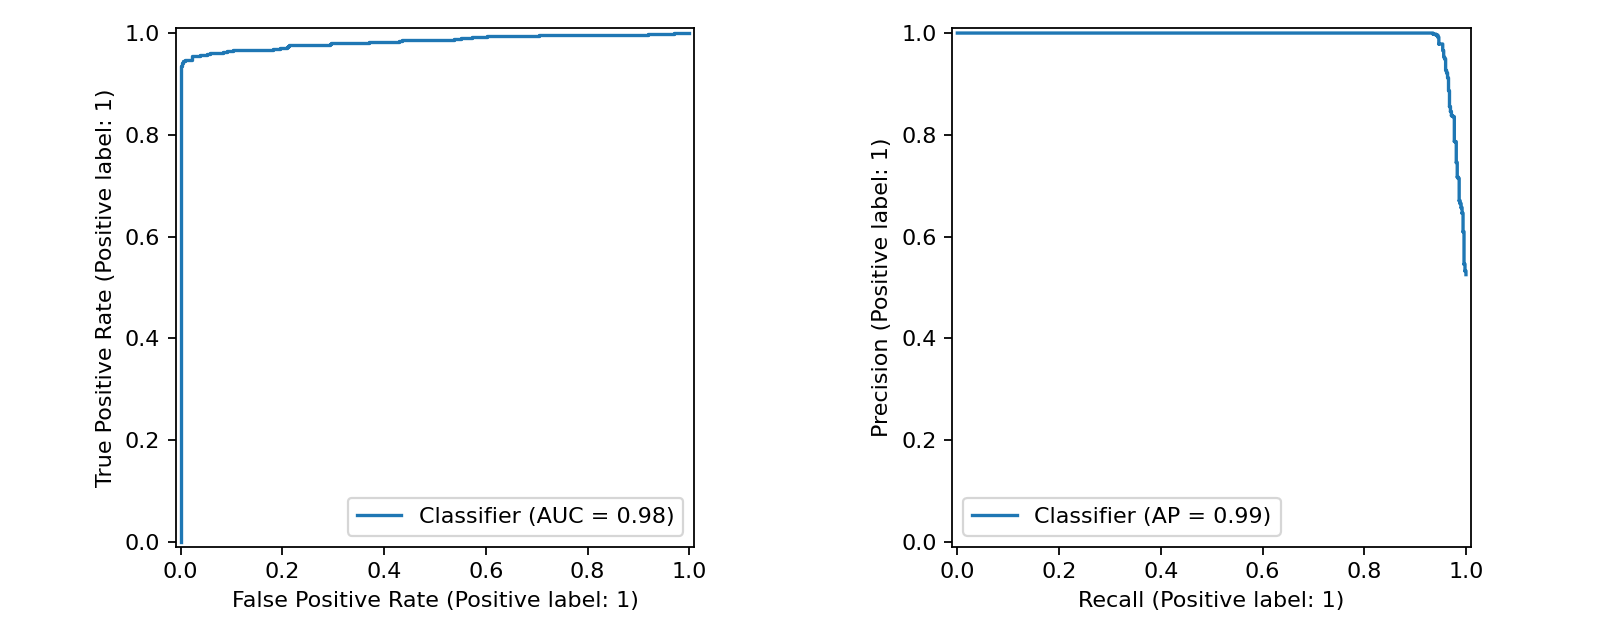

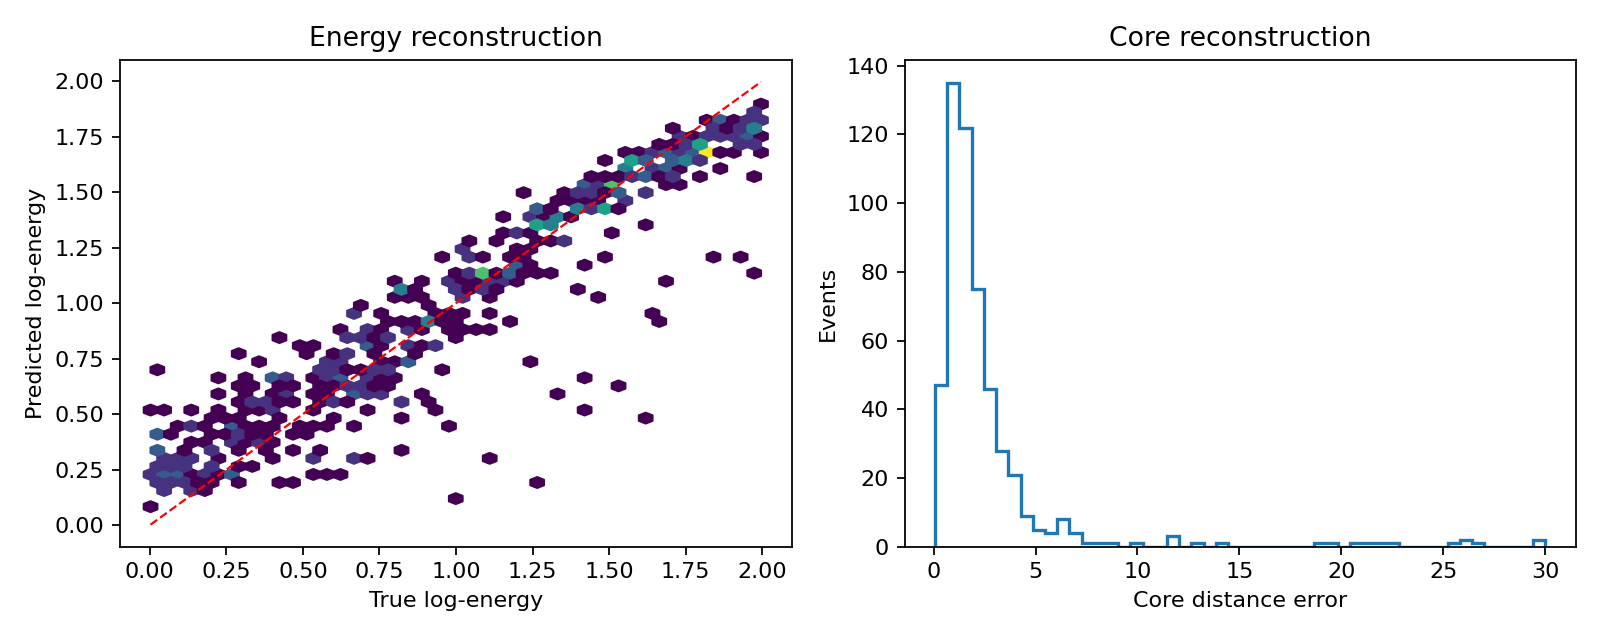

In [7]:
evaluation_split = "test" if RUN_MODE == "full" and EVALUATE_TEST else "val"
evaluation_dir = OUTPUT_DIR / f"evaluation_{evaluation_split}"
command = [
    sys.executable, "-m", "cosmic_ml.evaluate",
    "--checkpoint", str(OUTPUT_DIR / "best.pt"),
    "--data-dir", str(DATA_DIR),
    "--split", evaluation_split,
    "--batch-size", "128",
    "--num-workers", "2" if IN_COLAB else "0",
    "--device", "cuda" if torch.cuda.is_available() else "cpu",
    "--output-dir", str(evaluation_dir),
]
if RUN_MODE == "quick" or smoke:
    command += ["--max-samples", "64" if smoke else "1000"]
subprocess.run(command, check=True)

metrics = json.loads((evaluation_dir / "metrics.json").read_text())
print(f"{MODEL_VARIANT.title()} {RUN_MODE} result on {evaluation_split}:")
print(json.dumps(metrics, indent=2))

from IPython.display import display, Image
display(Image(filename=str(evaluation_dir / "classification_curves.png")))
display(Image(filename=str(evaluation_dir / "reconstruction.png")))

## 9. Full-run model comparison

The following values are loaded from the checked-in provenance file. The following reference metrics come from completed **7,500-event test evaluations**, not from the quick notebook run. They are shown separately so that demonstration results are not confused with the final experiment.

In [8]:
reference = json.loads((PROJECT_ROOT / "results" / "reference_metrics.json").read_text())
metrics_to_show = [
    "classification/roc_auc",
    "classification/accuracy_at_0.5",
    "classification/brier",
    "energy/mae",
    "energy/rmse",
    "core/median_distance",
    "core/p68_distance",
]
header = "| Metric | Original | Attention |\n|---|---:|---:|\n"
rows = "".join(
    f"| {name} | {reference['original'][name]:.6f} | {reference['attention'][name]:.6f} |\n"
    for name in metrics_to_show
)
from IPython.display import Markdown
display(Markdown(header + rows))
print(reference["provenance"])

| Metric | Original | Attention |
|---|---:|---:|
| classification/roc_auc | 0.990187 | 0.989556 |
| classification/accuracy_at_0.5 | 0.983333 | 0.985333 |
| classification/brier | 0.014667 | 0.013468 |
| energy/mae | 0.084422 | 0.082830 |
| energy/rmse | 0.141148 | 0.142062 |
| core/median_distance | 0.642900 | 0.613031 |
| core/p68_distance | 0.941659 | 0.875752 |


Frozen local GPU test runs completed on 2026-09-01; these are reference values, not Colab reruns.


## 10. Interpretation and conclusion

- The baseline Deep Sets model is compact, permutation invariant, and easy to relate to the detector structure.
- Attention adds only a small scoring network and improves accuracy, Brier score, energy MAE, and core-error summaries in the completed comparison.
- Attention slightly worsens ROC-AUC, PR-AUC, and energy RMSE, so the conclusion is a reconstruction trade-off rather than a universal victory.
- Local GPU execution is the canonical full experiment because storage and hardware persist. Colab provides a portable demonstration environment and can attempt a full run, but its GPU type, availability, and runtime lifetime are not guaranteed.
- Reproducibility includes the split seed, training-only normalization, explicit signal masking, saved runtime versions, separate output directories, and provenance-labeled reference metrics.